1) MOUNT GOOGLE DRIVE





In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. EXTRACT DATASET FROM DRIVE

In [3]:
import zipfile
import os
zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/bengali_dataset'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")
print("Contents:", os.listdir(extract_path))

Dataset Extracted Successfully!
Contents: ['basicfinal', 'BasicFinalDatabase']


3. EXPLORE DATASET STRUCTURE

Top-level folders:
['basicfinal', 'BasicFinalDatabase']

Total images found: 30000
Sample path: /content/bengali_dataset/basicfinal/basicfinal/Test/197/bcc000038.bmp

Using Train Path: /content/bengali_dataset/basicfinal/basicfinal/Train
Number of Classes: 50
Class Labels: ['172', '173', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '200', '201', '202', '203', '204', '205', '206', '207', '208', '209', '210', '211', '212', '213', '214', '215', '216', '217', '218', '219', '220', '221']

Images per Class:
Class 172: 168 images
Class 173: 168 images
Class 174: 168 images
Class 175: 168 images
Class 176: 168 images
Class 177: 168 images
Class 178: 168 images
Class 179: 168 images
Class 180: 168 images
Class 181: 168 images
Class 182: 168 images
Class 183: 168 images
Class 184: 168 images
Class 185: 168 images
Class 186: 168 images
Class 187: 168 images
Clas

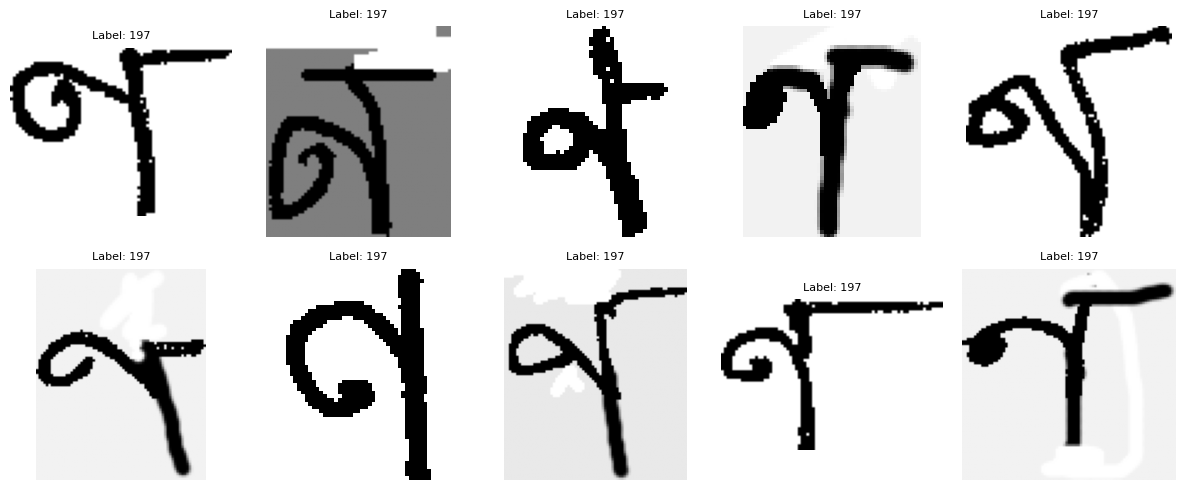

In [4]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

# ── Find the correct base path ──
base_path = '/content/bengali_dataset'

print("Top-level folders:")
print(os.listdir(base_path))

# ── Find ALL .bmp images recursively ──
all_images = glob.glob(base_path + '/**/*.bmp', recursive=True)

print(f"\nTotal images found: {len(all_images)}")

if len(all_images) > 0:
    print("Sample path:", all_images[0])

# ── Find the correct Train folder ──
possible_train = [
    '/content/bengali_dataset/basicfinal/basicfinal/Train',
    '/content/bengali_dataset/BasicFinalDatabase/BasicFinalDatabase/Train'
]

train_path = None

for p in possible_train:
    if os.path.exists(p):
        train_path = p
        break

# ── Verify Train Path ──
if train_path is not None:

    print(f"\nUsing Train Path: {train_path}")

    classes = sorted(os.listdir(train_path))

    print(f"Number of Classes: {len(classes)}")
    print(f"Class Labels: {classes}")

    # Count images per class
    print("\nImages per Class:")

    total_images = 0

    for cls in classes:
        class_path = os.path.join(train_path, cls)

        count = len(
            glob.glob(class_path + '/*.bmp')
        )

        total_images += count

        print(f"Class {cls}: {count} images")

    print(f"\nTotal Training Images: {total_images}")

    # ── Display 10 Sample Images ──
    sample_images = glob.glob(
        train_path + '/**/*.bmp',
        recursive=True
    )[:10]

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):

        img = cv2.imread(
            sample_images[i],
            cv2.IMREAD_GRAYSCALE
        )

        label = sample_images[i].split('/')[-2]

        ax.imshow(img, cmap='gray')
        ax.set_title(f"Label: {label}", fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Train folder not found!")

4. LOAD ALL IMAGES+LABEL

In [5]:
import os
import cv2
import numpy as np

images = []
labels = []
failed = 0

# Load data from all available dataset folders
data_dirs = [
    '/content/bengali_dataset/basicfinal/basicfinal/Train',
    '/content/bengali_dataset/basicfinal/basicfinal/Val',
    '/content/bengali_dataset/basicfinal/basicfinal/Test',
    '/content/bengali_dataset/BasicFinalDatabase/BasicFinalDatabase/Train',
    '/content/bengali_dataset/BasicFinalDatabase/BasicFinalDatabase/Val',
    '/content/bengali_dataset/BasicFinalDatabase/BasicFinalDatabase/Test'
]

for base in data_dirs:

    # Skip folder if it does not exist
    if not os.path.exists(base):
        continue

    print(f"\nLoading from: {base}")

    for label_folder in sorted(os.listdir(base)):

        folder_path = os.path.join(base, label_folder)

        # Ensure it is a directory
        if not os.path.isdir(folder_path):
            continue

        for img_file in os.listdir(folder_path):

            # Only BMP images
            if not img_file.endswith('.bmp'):
                continue

            img_path = os.path.join(folder_path, img_file)

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            # Skip corrupted images
            if img is None:
                failed += 1
                continue

            images.append(img)
            labels.append(label_folder)

print("\n============================")
print(f"Loaded Images : {len(images)}")
print(f"Failed Images : {failed}")
print(f"Unique Labels : {len(set(labels))}")
print(f"Class Labels  : {sorted(set(labels))}")
print("============================")


Loading from: /content/bengali_dataset/basicfinal/basicfinal/Train

Loading from: /content/bengali_dataset/basicfinal/basicfinal/Val

Loading from: /content/bengali_dataset/basicfinal/basicfinal/Test

Loading from: /content/bengali_dataset/BasicFinalDatabase/BasicFinalDatabase/Train

Loading from: /content/bengali_dataset/BasicFinalDatabase/BasicFinalDatabase/Test

Loaded Images : 30000
Failed Images : 0
Unique Labels : 50
Class Labels  : ['172', '173', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '200', '201', '202', '203', '204', '205', '206', '207', '208', '209', '210', '211', '212', '213', '214', '215', '216', '217', '218', '219', '220', '221']


5. Preprocess-resize, normalize, reshape

In [6]:
import numpy as np
import cv2

IMG_SIZE = 64  # All images resized to 64x64

# Step 1: Resize every image
images_resized = [
    cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    for img in images
]

# Step 2: Convert to NumPy array
X = np.array(images_resized)

# Step 3: Normalize pixel values
# (0-255 → 0.0-1.0)
X = X / 255.0

# Step 4: Add channel dimension
# (64,64) → (64,64,1)
# CNN expects:
# (samples, height, width, channels)

X = X.reshape(
    -1,
    IMG_SIZE,
    IMG_SIZE,
    1
)

# Convert labels to NumPy array
y = np.array(labels)

# Display dataset information
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Pixel range: {X.min():.2f} to {X.max():.2f}")

X shape: (30000, 64, 64, 1)
y shape: (30000,)
Pixel range: 0.00 to 1.00


6. LABEL ENCODE

In [7]:
from sklearn.preprocessing import LabelEncoder

# Create encoder object
encoder = LabelEncoder()

# Convert string labels to integer labels
y_encoded = encoder.fit_transform(y)

# Display sample mappings
print("Sample Original Labels:")
print(y[:5])

print("\nSample Encoded Labels:")
print(y_encoded[:5])

# Total number of classes
print(f"\nTotal Classes: {len(encoder.classes_)}")

# Show all class labels
print("\nAll Class Labels:")
print(encoder.classes_)

# Example: Reverse mapping
# encoder.inverse_transform([13])

Sample Original Labels:
['172' '172' '172' '172' '172']

Sample Encoded Labels:
[0 0 0 0 0]

Total Classes: 50

All Class Labels:
['172' '173' '174' '175' '176' '177' '178' '179' '180' '181' '182' '183'
 '184' '185' '186' '187' '188' '189' '190' '191' '192' '193' '194' '195'
 '196' '197' '198' '199' '200' '201' '202' '203' '204' '205' '206' '207'
 '208' '209' '210' '211' '212' '213' '214' '215' '216' '217' '218' '219'
 '220' '221']


7. TRAIN/TEST SPLIT

In [8]:
from sklearn.model_selection import train_test_split

# Split dataset into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,          # 20% for testing
    random_state=42,        # Reproducibility
    stratify=y_encoded      # Maintain class balance
)

# Display dataset information
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")

print(f"\nX_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")

print(f"\ny_train Shape: {y_train.shape}")
print(f"y_test Shape: {y_test.shape}")

Training Samples: 24000
Testing Samples: 6000

X_train Shape: (24000, 64, 64, 1)
X_test Shape: (6000, 64, 64, 1)

y_train Shape: (24000,)
y_test Shape: (6000,)


**PHASE C -- MODEL BUILDING**

8. BUILD MODEL- 3BLOCK CNN

In [9]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout,
    Input
)

# Number of Bengali character classes
num_classes = len(encoder.classes_)

print(f"Building model for {num_classes} classes")

# CNN Model
model = Sequential([

    # Input Layer
    Input(shape=(64, 64, 1)),

    # ── Convolution Block 1 ──
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # ── Convolution Block 2 ──
    Conv2D(
        64,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # ── Convolution Block 3 ──
    Conv2D(
        128,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # ── Classification Head ──
    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        num_classes,
        activation='softmax'
    )
])

# Display Model Architecture
model.summary()

Building model for 50 classes


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,203,826 (8.41 MB)

 Trainable params: 2,203,378 (8.41 MB)

 Non-trainable params: 448 (1.75 KB)

9. COMPILE MODEL

In [10]:
model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] )
print(" Model compiled!")
print(" Optimizer: Adam")
print(" Loss: sparse_categorical_crossentropy")
print(" Metric: accuracy")

 Model compiled!
 Optimizer: Adam
 Loss: sparse_categorical_crossentropy
 Metric: accuracy


10. DATA AUGMENTATION

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create data augmentation generator
datagen = ImageDataGenerator(

    rotation_range=10,        # Rotate ±10 degrees

    zoom_range=0.1,           # Zoom in/out by 10%

    width_shift_range=0.1,    # Shift left/right

    height_shift_range=0.1,   # Shift up/down

    shear_range=0.1,          # Slight skew

    horizontal_flip=False     # Do NOT flip Bengali characters
)

# Learn statistics from training data
datagen.fit(X_train)

print(" Data augmentation ready!")

 Data augmentation ready!


11. CALLBACKS -- earlystopping+LR redure

In [13]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',           # Watch validation loss
    patience=5,                   # Stop after 5 epochs without improvement
    restore_best_weights=True     # Restore the best model weights
)

# Reduce Learning Rate on Plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                   # Halve the learning rate
    patience=3,                   # Wait 3 epochs before reducing
    min_lr=0.00001                # Minimum learning rate
)

print("Callbacks ready!")

Callbacks ready!


**PHASE D -- TRAINING**

12. TRAINING THE MODEL

In [14]:
history = model.fit(

    datagen.flow(
        X_train,
        y_train,
        batch_size=32
    ),

    epochs=30,

    validation_data=(
        X_test,
        y_test
    ),

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

# ── Training Results ──

final_train_acc = history.history['accuracy'][-1]

final_val_acc = history.history['val_accuracy'][-1]

best_val_acc = max(
    history.history['val_accuracy']
)

print("\nTraining Complete!")

print(
    f"Final Train Accuracy: "
    f"{final_train_acc * 100:.1f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{final_val_acc * 100:.1f}%"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc * 100:.1f}%"
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.2623 - loss: 2.9262 - val_accuracy: 0.6790 - val_loss: 1.0696 - learning_rate: 0.0010
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.4888 - loss: 1.7952 - val_accuracy: 0.7910 - val_loss: 0.6408 - learning_rate: 0.0010
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.5777 - loss: 1.4403 - val_accuracy: 0.8183 - val_loss: 0.5786 - learning_rate: 0.0010
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.6479 - loss: 1.1717 - val_accuracy: 0.9015 - val_loss: 0.3169 - learning_rate: 0.0010
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.7132 - loss: 0.9430 - val_accuracy: 0.9067 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.7490 - loss: 0.8282 - val_accuracy: 0.9252 - val_loss: 0.2441 - learning_rate: 0.0010
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7797 - l

13. PLOT ACCURACY AND LOSS CURVES

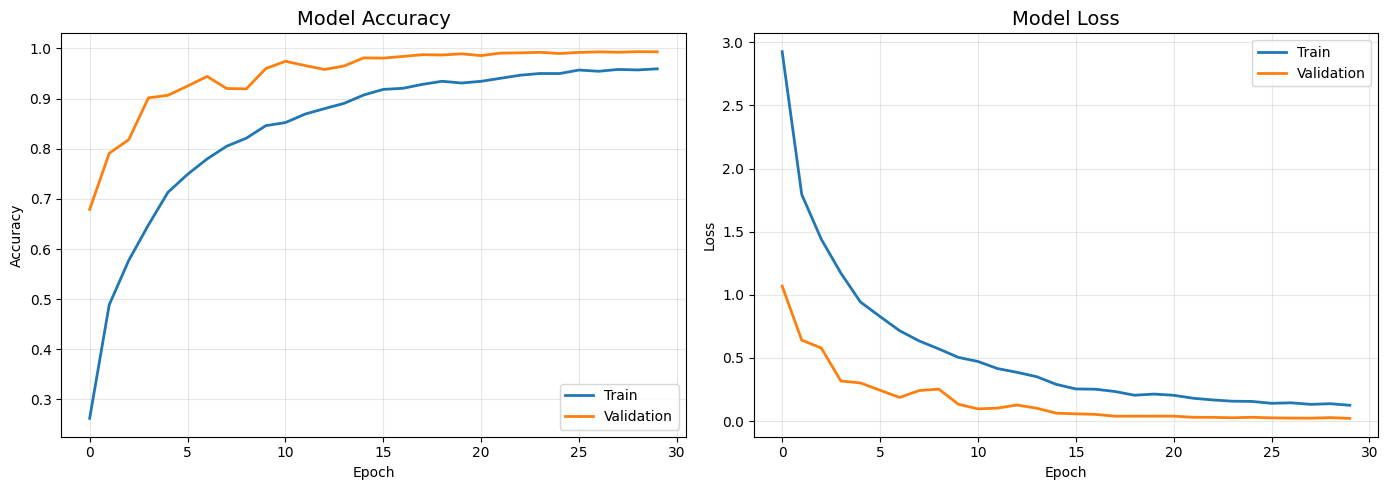

Plot saved as training_curves.png


In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# ── Accuracy ──
ax1.plot(
    history.history['accuracy'],
    label='Train',
    linewidth=2
)

ax1.plot(
    history.history['val_accuracy'],
    label='Validation',
    linewidth=2
)

ax1.set_title(
    'Model Accuracy',
    fontsize=14
)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')

ax1.legend()

ax1.grid(
    True,
    alpha=0.3
)

# ── Loss ──
ax2.plot(
    history.history['loss'],
    label='Train',
    linewidth=2
)

ax2.plot(
    history.history['val_loss'],
    label='Validation',
    linewidth=2
)

ax2.set_title(
    'Model Loss',
    fontsize=14
)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')

ax2.legend()

ax2.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    'training_curves.png',
    dpi=150
)

plt.show()

print("Plot saved as training_curves.png")

**PHASE E--- SAVING AND TESTING**

14. Complete Bengali Character Map (all 50 classes)

In [16]:
bengali_map = {

    '172': 'অ',
    '173': 'আ',
    '174': 'ই',
    '175': 'ঈ',
    '176': 'উ',
    '177': 'ঊ',
    '178': 'ঋ',
    '179': 'এ',
    '180': 'ঐ',
    '181': 'ও',
    '182': 'ঔ',
    '183': 'ক',
    '184': 'খ',
    '185': 'গ',
    '186': 'ঘ',
    '187': 'ঙ',
    '188': 'চ',
    '189': 'ছ',
    '190': 'জ',
    '191': 'ঝ',
    '192': 'ঞ',
    '193': 'ট',
    '194': 'ঠ',
    '195': 'ড',
    '196': 'ঢ',
    '197': 'ণ',
    '198': 'ত',
    '199': 'থ',
    '200': 'দ',
    '201': 'ধ',
    '202': 'ন',
    '203': 'প',
    '204': 'ফ',
    '205': 'ব',
    '206': 'ভ',
    '207': 'ম',
    '208': 'য',
    '209': 'র',
    '210': 'ল',
    '211': 'শ',
    '212': 'ষ',
    '213': 'স',
    '214': 'হ',
    '215': 'ড়',
    '216': 'ঢ়',
    '217': 'য়',
    '218': 'ৎ',
    '219': 'ং',
    '220': 'ঃ',
    '221': 'ঁ'

}

print(
    f"Map has {len(bengali_map)} characters"
)

print(
    "Sample: label 185 →",
    bengali_map['185']
)

print(
    "All characters:",
    ' '.join(bengali_map.values())
)

Map has 50 characters
Sample: label 185 → গ
All characters: অ আ ই ঈ উ ঊ ঋ এ ঐ ও ঔ ক খ গ ঘ ঙ চ ছ জ ঝ ঞ ট ঠ ড ঢ ণ ত থ দ ধ ন প ফ ব ভ ম য র ল শ ষ স হ ড় ঢ় য় ৎ ং ঃ ঁ


15. Save model, encoder and map

In [17]:
import json
import numpy as np

# ── 1. Save the trained model ──
model.save('bengali_ocr_model.keras')

print(
    "Model saved: bengali_ocr_model.keras"
)

# ── 2. Save encoder classes ──
np.save(
    'label_classes.npy',
    encoder.classes_
)

print(
    "Encoder saved: label_classes.npy"
)

# ── 3. Save Bengali map ──
with open(
    'bengali_map.json',
    'w',
    encoding='utf-8'
) as f:

    json.dump(
        bengali_map,
        f,
        ensure_ascii=False,
        indent=2
    )

print(
    "Map saved: bengali_map.json"
)

# ── Verify all 3 files exist ──
import os

for fname in [
    'bengali_ocr_model.keras',
    'label_classes.npy',
    'bengali_map.json'
]:

    size = os.path.getsize(fname)

    print(
        f"{fname}: {size/1024:.0f} KB"
    )

Model saved: bengali_ocr_model.keras
Encoder saved: label_classes.npy
Map saved: bengali_map.json
bengali_ocr_model.keras: 25886 KB
label_classes.npy: 1 KB
bengali_map.json: 1 KB


16. Test prediction on sample image

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2467 (\N{BENGALI LETTER NNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)


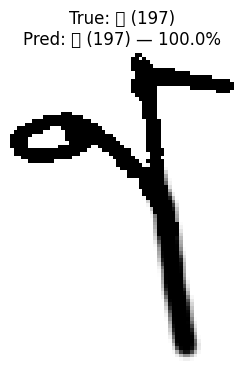

CORRECT | True: ণ Predicted: ণ Confidence: 100.0%


In [18]:
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder

import json

# Load everything fresh (simulates what app.py will do)
test_model = load_model(
    'bengali_ocr_model.keras'
)

test_classes = np.load(
    'label_classes.npy',
    allow_pickle=True
)

test_encoder = LabelEncoder()

test_encoder.classes_ = test_classes

with open(
    'bengali_map.json',
    'r',
    encoding='utf-8'
) as f:

    test_map = json.load(f)

# Pick a random test image
test_imgs = glob.glob(
    '/content/bengali_dataset/**/*.bmp',
    recursive=True
)

test_path = test_imgs[42]  # Change index to try different images

true_label = test_path.split('/')[-2]

# Preprocess exactly like training
img_raw = cv2.imread(
    test_path,
    cv2.IMREAD_GRAYSCALE
)

img_sized = cv2.resize(
    img_raw,
    (64, 64)
)

img_norm = img_sized / 255.0

img_input = img_norm.reshape(
    1,
    64,
    64,
    1
)

# Predict
pred = test_model.predict(
    img_input,
    verbose=0
)

pred_idx = np.argmax(pred)

confidence = np.max(pred) * 100

pred_label = test_encoder.inverse_transform(
    [pred_idx]
)[0]

pred_char = test_map.get(
    str(pred_label),
    '?'
)

true_char = test_map.get(
    str(true_label),
    '?'
)

# Display
plt.figure(figsize=(4, 4))

plt.imshow(
    img_raw,
    cmap='gray'
)

plt.title(
    f"True: {true_char} ({true_label})\n"
    f"Pred: {pred_char} ({pred_label}) — "
    f"{confidence:.1f}%"
)

plt.axis('off')

plt.show()

correct = (
    "CORRECT"
    if pred_label == true_label
    else "WRONG"
)

print(
    f"{correct} | "
    f"True: {true_char} "
    f"Predicted: {pred_char} "
    f"Confidence: {confidence:.1f}%"
)

17. Download Model files to pc

In [19]:
from google.colab import files

print("Downloading 3 files...")

files.download(
    'bengali_ocr_model.keras'
)

files.download(
    'label_classes.npy'
)

files.download(
    'bengali_map.json'
)

print("All 3 files downloaded!")

print("Save them somewhere safe on your computer.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All 3 files downloaded!
Save them somewhere safe on your computer.


18. Create app.py(Streamlit frontend)

In [32]:
app_code = '''
import streamlit as st
import numpy as np
import cv2
import json

from PIL import Image
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder

st.set_page_config(
    page_title="Bengali OCR",
    page_icon="🔤",
    layout="centered"
)

@st.cache_resource
def load_resources():

    model = load_model("bengali_ocr_model.keras")

    classes = np.load(
        "label_classes.npy",
        allow_pickle=True
    )

    enc = LabelEncoder()
    enc.classes_ = classes

    with open(
        "bengali_map.json",
        "r",
        encoding="utf-8"
    ) as f:

        bmap = json.load(f)

    return model, enc, bmap

model, encoder, bengali_map = load_resources()

# ── Header ──────────────────────────────────────────

st.title("🔤 Bengali Handwriting Recognition")

st.markdown(
    "Upload a handwritten **Bengali character** image."
)

st.markdown("---")

# ── Upload ───────────────────────────────────────────

uploaded_file = st.file_uploader(
    "Upload image (JPG / PNG / BMP)",
    type=["jpg", "jpeg", "png", "bmp"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file)

    col1, col2 = st.columns(2)

    with col1:

        st.subheader("Uploaded image")

        st.image(
            image,
            use_column_width=True
        )

    # ── Preprocess ────────────────────────────────────

    img_array = np.array(
        image.convert("L")
    )

    img_resized = cv2.resize(
        img_array,
        (64, 64)
    )

    img_norm = img_resized / 255.0

    img_input = img_norm.reshape(
        1,
        64,
        64,
        1
    )

    # ── Predict ───────────────────────────────────────

    pred = model.predict(img_input)

    pred_idx = int(np.argmax(pred))

    confidence = float(np.max(pred)) * 100

    pred_label = encoder.inverse_transform(
        [pred_idx]
    )[0]

    pred_char = bengali_map.get(
        str(pred_label),
        "?"
    )

    with col2:

        st.subheader("Prediction")

        st.markdown(
            f"""

# {pred_char}

**Label:** {pred_label}

**{confidence:.1f}% confidence**

""",
            unsafe_allow_html=True
        )

    # ── Top 5 ─────────────────────────────────────────

    st.markdown("---")

    st.subheader("Top 5 predictions")

    top5 = np.argsort(
        pred[0]
    )[::-1][:5]

    for rank, idx in enumerate(top5, 1):

        lbl = encoder.inverse_transform(
            [idx]
        )[0]

        char = bengali_map.get(
            str(lbl),
            "?"
        )

        conf = float(pred[0][idx] * 100)

        st.markdown(
            f"**#{rank}** {char} — label {lbl}"
        )

        st.progress(float(conf) / 100)

# ── Sidebar ──────────────────────────────────────────

st.sidebar.title("About")

st.sidebar.info(
    "Bengali OCR using CNN trained on CMATERdb\\n\\n"
    f"Classes: 50 Bengali characters\\n\\n"
    "Upload a single handwritten character image to test."
)
'''

with open(
    'app.py',
    'w',
    encoding='utf-8'
) as f:

    f.write(app_code)

print("app.py created!")

print(
    "Check it exists:",
    os.path.exists('app.py')
)

app.py created!
Check it exists: True


19. Run Streamlit+get public URL via ngrok

In [24]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 86.8 MB/s eta 0:00:00


In [25]:
!which streamlit

/usr/local/bin/streamlit


In [27]:
from pyngrok import ngrok

ngrok.set_auth_token(
    "3EoTDCAL8M20PJ0W7WpZmqNVKkA_7jNGAWMmjYHU9ruPxZC8Q"
)

print("ngrok authenticated")

ngrok authenticated


In [28]:
!pip install streamlit pyngrok -q

In [30]:
from pyngrok import ngrok
import subprocess
import time

ngrok.set_auth_token(
    "3EoTDCAL8M20PJ0W7WpZmqNVKkA_7jNGAWMmjYHU9ruPxZC8Q"
)

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501"
    ]
)

time.sleep(10)

public_url = ngrok.connect(8501)

print("App URL:")
print(public_url)

App URL:
NgrokTunnel: "https://widow-sectional-bottle.ngrok-free.dev" -> "http://localhost:8501"
